# Synthetic Data Experiment Series
### cylmix-2d-low-strong
- Data generator: Mixture of Cylindrical distribution
- Data dimension: 2d
- Separability between clusters: low
- Cross-correlation: strong


## 01 - Data Generation

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#%matplotlib widget
import cyl_lvm as clvm
from experiment.synthetic_data import experiment_helper as mod

rng = np.random.RandomState(7)
D_GAUSS = 2
D_VMF = 2
N = 10000

In [2]:
# cylmix-2d-low-strong
angles = np.deg2rad([0.0, 25.0, -25.0])

cyl_components = [
    clvm.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.00, 0.00]),
        cross_corr=np.array([[0.781418827912, -0.446525044521],
                             [0.659806266860, 0.612091243371]]),
        unconditional_gauss_cov=np.array([[2.520, 0.556],
                                          [0.556, 1.590]]),
        mu_vmf=mod.unit([np.cos(angles[0]), np.sin(angles[0])]),
        kappa=5.0,
    ),

    clvm.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.45, 0.20]),
        cross_corr=np.array([[-0.674854069828, 0.595459473379],
                             [-0.266577716918, -0.859614053423]]),
        unconditional_gauss_cov=np.array([[2.128, -0.728],
                                          [-0.728, 2.260]]),
        mu_vmf=mod.unit([np.cos(angles[1]), np.sin(angles[1])]),
        kappa=7.0,
    ),

    clvm.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.15, 0.55]),
        cross_corr=np.array([[0.595459473378, 0.674854069829],
                             [-0.810288165695, 0.391705359338]]),
        unconditional_gauss_cov=np.array([[2.3752, -0.4494],
                                          [-0.4494, 1.9510]]),
        mu_vmf=mod.unit([np.cos(angles[2]), np.sin(angles[2])]),
        kappa=4.5,
    ),
]

cyl_weights = np.array([0.36, 0.34, 0.30], dtype=float)

generator = clvm.MixtureModel(components=cyl_components,
                              weights=cyl_weights,
                              init="k-means",
                              rng=rng)

# create sample
x, labels = generator.sample(N, rng=rng, return_labels=True)
x_gauss = x[:, :D_GAUSS]
x_vmf = x[:, D_GAUSS:]

# medium noise setup
sigma_g = 0.15 * np.maximum(x_gauss.std(axis=0, ddof=1), 1e-8)
sigma_v = 0.05

noise_g = rng.normal(0.0, sigma_g, size=(N, D_GAUSS))
noise_v = rng.normal(0.0, sigma_v, size=(N, D_VMF))

x_noisy_gauss = noise_g + x_gauss
x_noisy_vmf = noise_v + x_vmf

# re-project directional block to unit sphere (required for vMF)
x_noisy_vmf = mod.unit(x_noisy_vmf)
x_noisy = np.concatenate((x_noisy_gauss, x_noisy_vmf), axis=1)

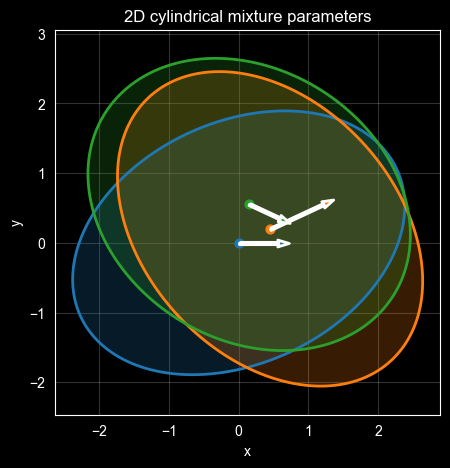

In [3]:
fig, ax = mod.plot_cylindrical_components_2d(generator, arrow_scale=1.0)

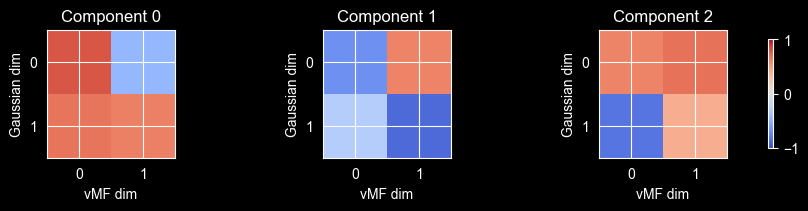

In [4]:
mod.plot_cross_corr_matrices(generator.components, cmap="coolwarm")

## 02 - Models training

In [5]:
setup = {"cylmix_l1": 3,
         "noisy_cylmix_l1": 3,
         "indcylmix_l1": 3,
         "noisy_indcylmix_l1": 3,
         "mom_l1": 4,
         "mom_l2": 2,
         "noisy_mom_l1": 4,
         "noisy_mom_l2": 2,
         "isomom_l1": 4,
         "isomom_l2": 2,
         "noisy_isomom_l1": 4,
         "noisy_isomom_l2": 2,
         }

In [6]:
models = mod.train_all_models(D_GAUSS, x, x_noisy,
                              setup=setup)
model_names = ["Cylindrical Mixture",
               "Cylindrical Mixture (noisy case)",
               "Independent Cylindrical Mixture",
               "Independent Cylindrical Mixture (noisy case)",
               "Two-layer MoM",
               "Two-layer MoM (noisy case)",
               "Isolated Two-layer MoM",
               "Isolated Two-layer MoM (noisy case)"]
cylmix, noisy_cylmix, indcylmix, noisy_indcylmix, mom, noisy_mom, isomom, noisy_isomom = models

EM iterations
Cylindrical mixture
   01 No noise: 48
   02 Noisy: 48
Independent cylindrical mixture
   03 No noise: 23
   04 Noisy: 25
Mixture of mixtures
   05 No noise: 36
   06 Noisy: 41
Isolation mixture of mixtures
   07 No noise: 214
   08 Noisy: 192


In [7]:
for i in range(4):
    models[i] = mod.align_cylindrical_mixture_to_generator(models[i], generator)

## 03 - Model comparison

The plots are showing four parameters:
- Ellipses perimeters are the unconditional Gaussian covariance matrices $\Sigma_{11}$.
- Ellipses centers are unconditional Gaussian mean $\mu_1$.
- Arrow directions are von Mises Fisher locations $\mu_2$.
- Arrow lengths are von Mises Fisher precision $\kappa$.

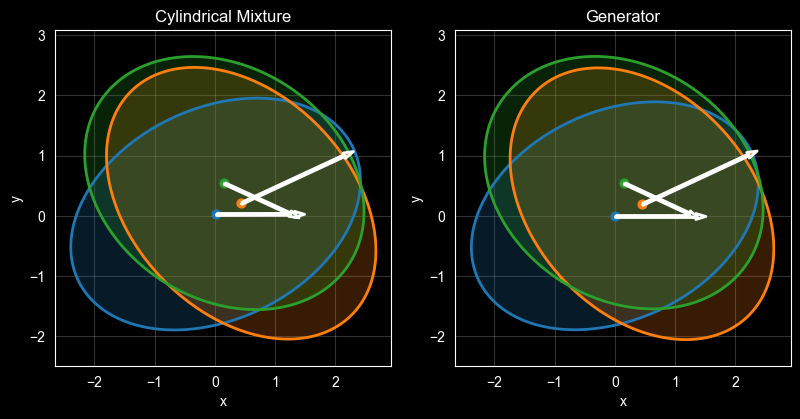

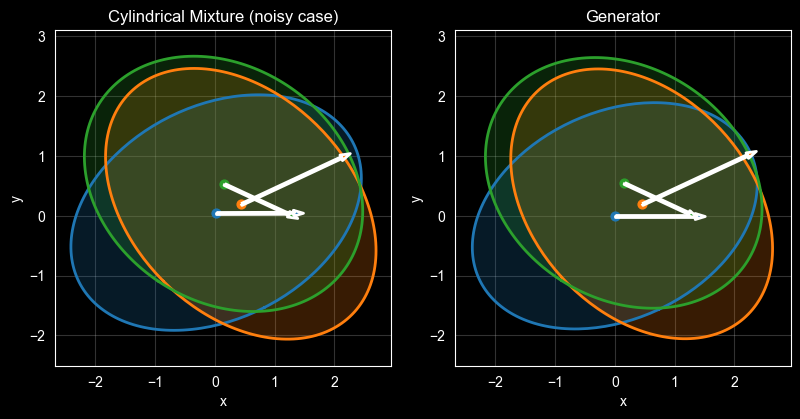

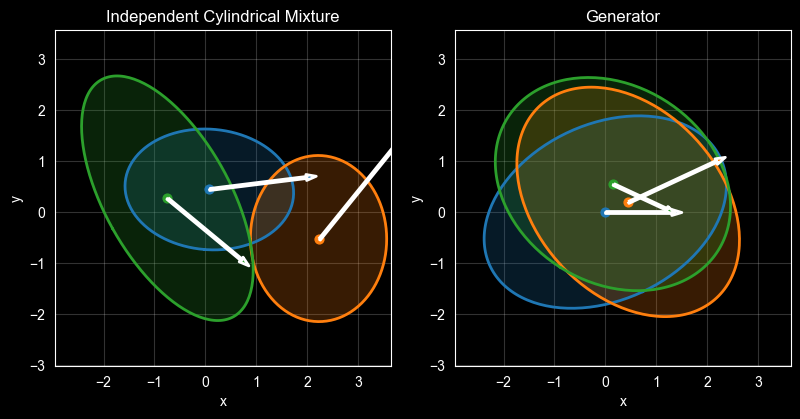

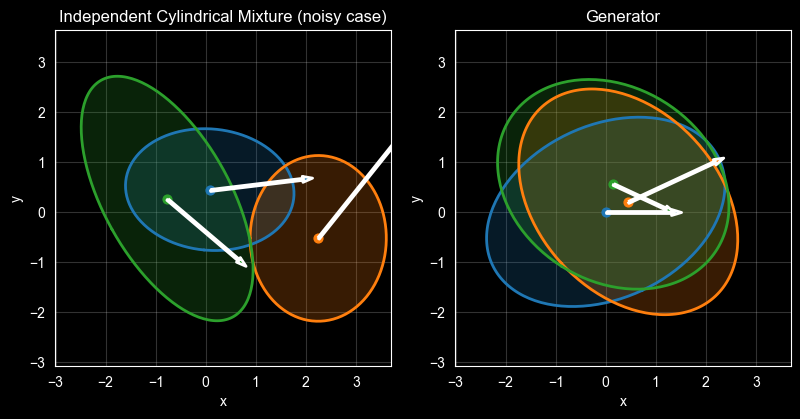

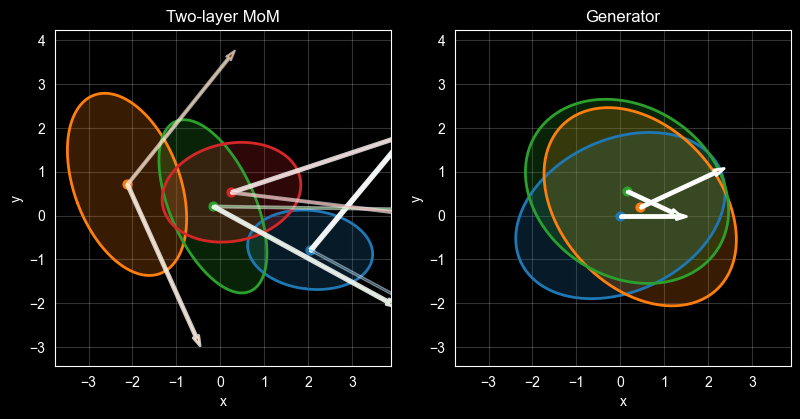

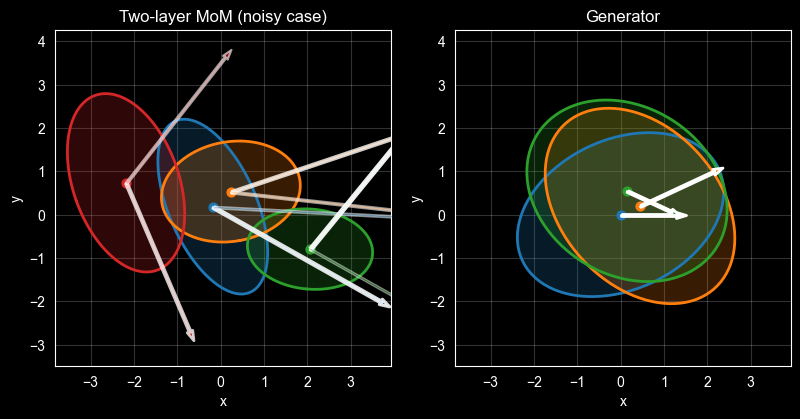

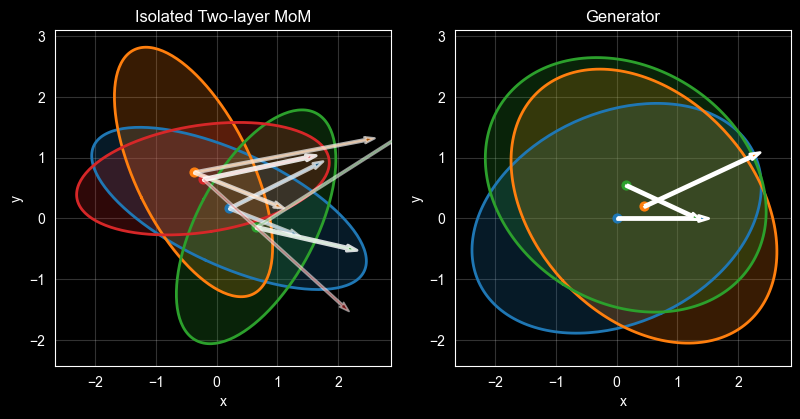

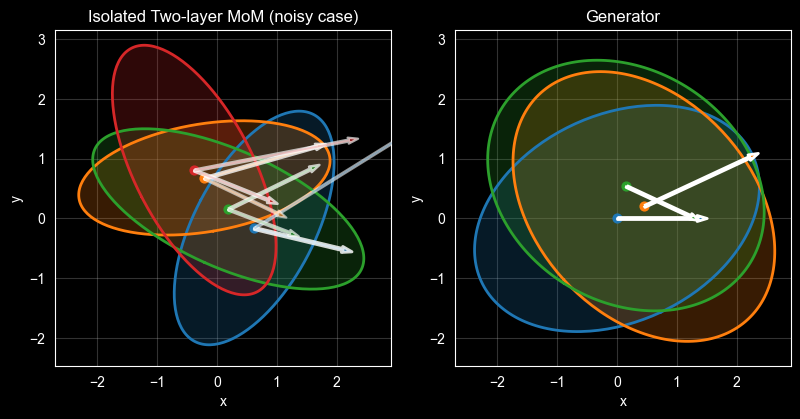

In [8]:
for model, name in zip(models, model_names):
    fig, axes = mod.plot_model_vs_generator_2d(
        model,
        generator,
        arrow_scale=0.3,
        generator_arrow_scale=0.3,
        normalize_kappa=False,
        title=name,
        figsize=(8, 4)
    )
    plt.show()

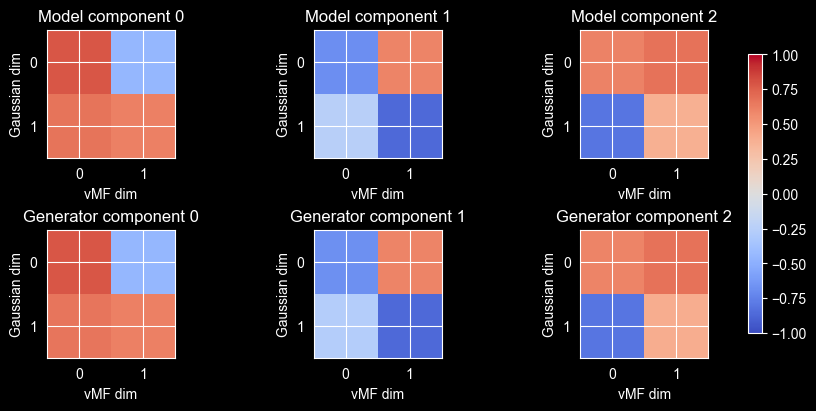

In [9]:
mod.plot_cross_corr_model_vs_generator(cylmix, generator, cmap="coolwarm")

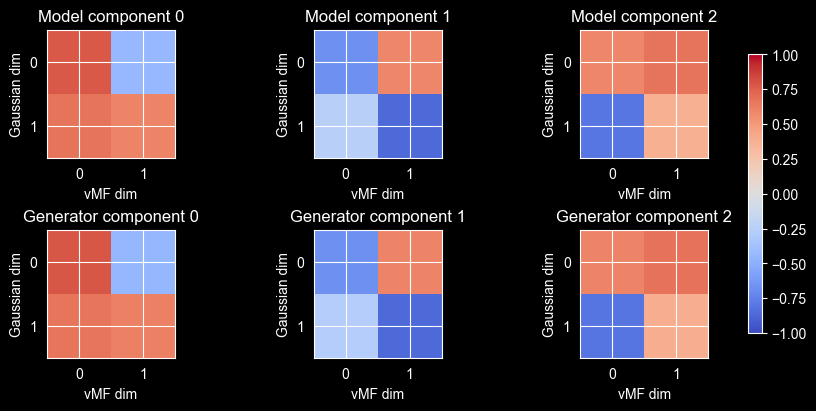

In [10]:
mod.plot_cross_corr_model_vs_generator(noisy_cylmix, generator, cmap="coolwarm")

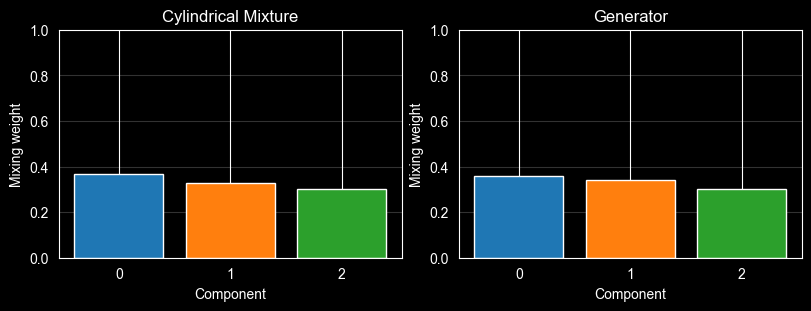

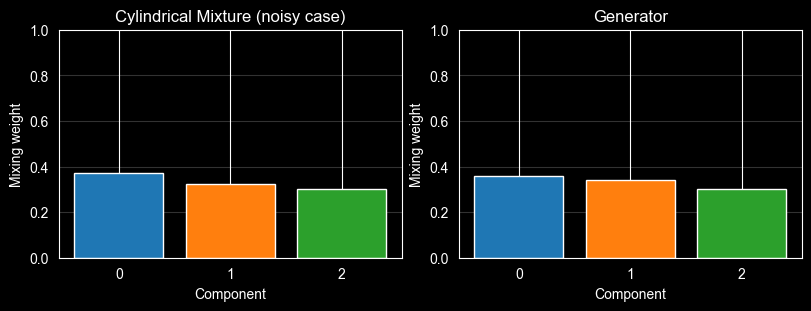

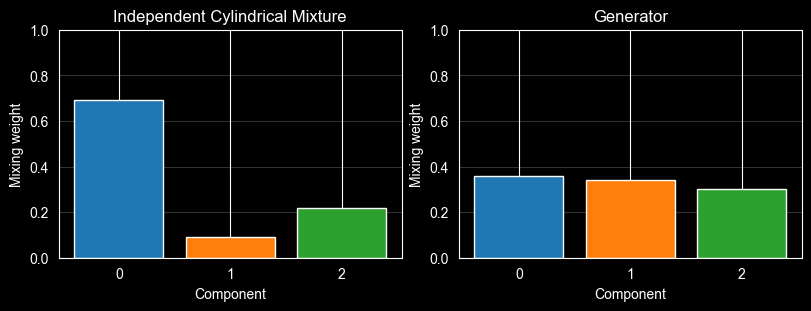

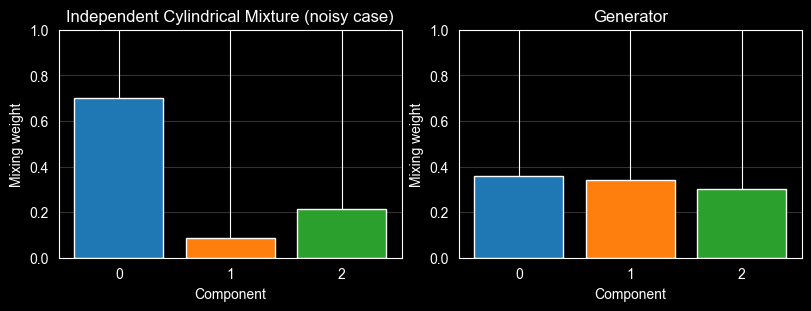

In [11]:
for model, name in zip(models[:4], model_names[:4]):
    fig, axes = mod.plot_mixing_weights_model_vs_generator(model, generator, title=name)
    plt.show()

## 04 - Metrics

In [12]:
N_test = 2000
x_test, labels_test = generator.sample(N_test, rng=rng, return_labels=True)

### 04.A - Adjusted Rand Index

In [13]:
results_ari = []
for model, name in zip(models[:4], model_names[:4]):
    results_ari.append(
        {"Model": name,
         "Sample": "in-sample",
         "ARI": clvm.ari(labels, model.predict(x))
         })
    results_ari.append(
        {"Model": name,
         "Sample": "out-of-sample",
         "ARI": clvm.ari(labels_test, model.predict(x_test))
         })

In [14]:
pd.DataFrame(results_ari)

,Model,Sample,ARI
0,Cylindrical Mixture,in-sample,0.675096
1,Cylindrical Mixture,out-of-sample,0.704883
2,Cylindrical Mixture (noisy case),in-sample,0.671655
3,Cylindrical Mixture (noisy case),out-of-sample,0.709781
4,Independent Cylindrical Mixture,in-sample,0.054861
5,Independent Cylindrical Mixture,out-of-sample,0.067320
6,Independent Cylindrical Mixture (noisy case),in-sample,0.052068
7,Independent Cylindrical Mixture (noisy case),out-of-sample,0.063765


### 04.B - Parameter Absolute Errors

In [19]:
results_errors = {}
for model, name in zip(models[:4], model_names[:4]):
    results_errors[name] = clvm.cylmix_comparison(generator, model)

comparison_df = mod.cylmix_comparison_dataframe(results_errors)
display(comparison_df)

,comparison,cond_cov,cross_cov,mu_gauss,mu_vmf,kappa_vmf
0,Cylindrical Mixture,0.00837,0.02408,0.03183,0.00166,0.12534
1,Cylindrical Mixture,0.01504,0.02523,0.01480,0.00133,0.17665
2,Cylindrical Mixture,0.02038,0.00863,0.01076,0.00479,0.04272
3,Cylindrical Mixture (noisy case),0.07286,0.03233,0.05875,0.00272,0.15385
4,Cylindrical Mixture (noisy case),0.05734,0.02908,0.01470,0.00120,0.30651
5,Cylindrical Mixture (noisy case),0.06684,0.00507,0.01679,0.00196,0.00059
6,Independent Cylindrical Mixture,0.82727,0.81598,0.45183,0.12337,2.04752
7,Independent Cylindrical Mixture,0.85143,0.71257,1.91694,0.45389,10.95193
8,Independent Cylindrical Mixture,2.79630,0.88245,0.93703,0.25544,2.42280
9,Independent Cylindrical Mixture (noisy case),0.87746,0.81598,0.45159,0.12037,1.84777


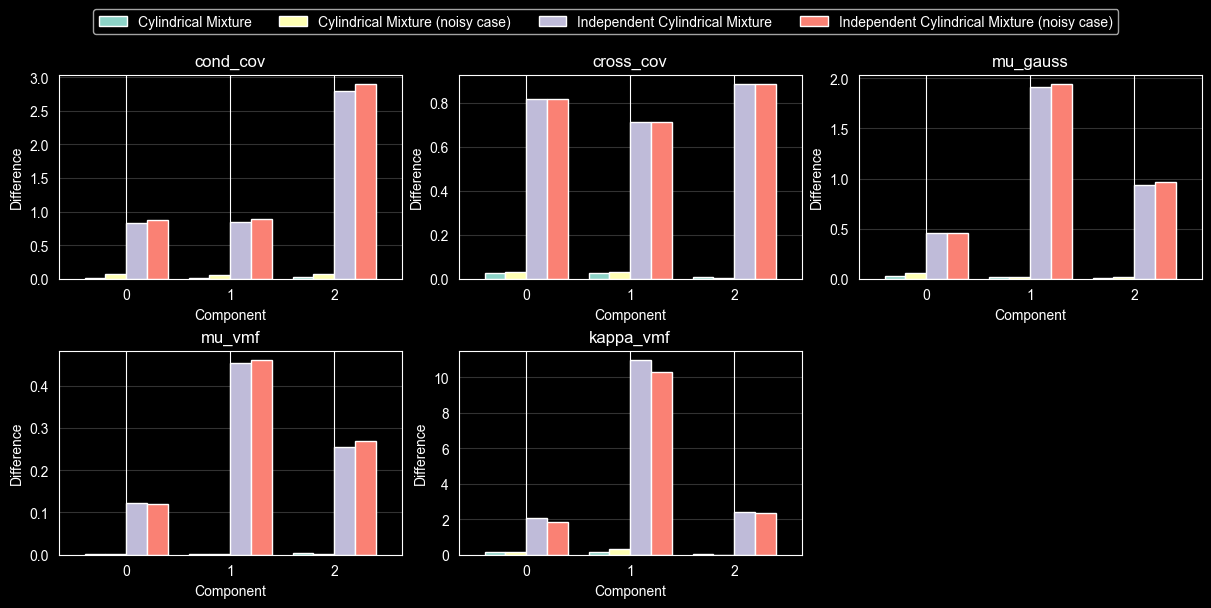

In [22]:
mod.plot_cylmix_comparison_metrics(comparison_df)

### 04.C - Held-out Loglikelihood

In [16]:
results_ll = []
for model, name in zip(models, model_names):
    if isinstance(model, clvm.MixtureModel):
        in_sample = model.score(x)
        oos = model.score(x_test)
    else:
        in_sample = model.score(x[:, :D_GAUSS], x[:, D_GAUSS:])
        oos = model.score(x_test[:, :D_GAUSS], x_test[:, D_GAUSS:])

    results_ll.append(
        {"Model": name,
         "Sample": "in-sample",
         "Avg. Log-likelihood": round(in_sample, 5)
         })
    results_ll.append(
        {"Model": name,
         "Sample": "out-of-sample",
         "Avg. Log-likelihood": round(oos, 5)
         })

In [17]:
pd.DataFrame(results_ll)

,Model,Sample,Avg. Log-likelihood
0,Cylindrical Mixture,in-sample,-3.37473
1,Cylindrical Mixture,out-of-sample,-3.38173
2,Cylindrical Mixture (noisy case),in-sample,-3.38034
3,Cylindrical Mixture (noisy case),out-of-sample,-3.38813
4,Independent Cylindrical Mixture,in-sample,-3.81672
5,Independent Cylindrical Mixture,out-of-sample,-3.84261
6,Independent Cylindrical Mixture (noisy case),in-sample,-3.81711
7,Independent Cylindrical Mixture (noisy case),out-of-sample,-3.84251
8,Two-layer MoM,in-sample,-3.70618
9,Two-layer MoM,out-of-sample,-3.75320
